In [1]:
import pandas as pd
fp = "../data/sba_loans_prepared/sba_loans_stage1.csv"
df = pd.read_csv(fp)

In [2]:
columns = ["BorrState","LoanStatus"]
df = df[columns]

In [3]:
df_borr_state = df.groupby(["BorrState"]).size().reset_index(name="borr_count")


In [4]:
sel_chgoff = df.LoanStatus == "CHGOFF"
df_chgoff = df[sel_chgoff].copy()
df_chgoff_value_counts = df_chgoff.BorrState.value_counts().reset_index()
df_chgoff_value_counts.columns = ["BorrState", "num_chgoffs"]

In [5]:

type(df_chgoff_value_counts)

pandas.DataFrame

In [6]:
df_borr_state = pd.merge(df_borr_state, df_chgoff_value_counts, on="BorrState")

In [7]:
df_borr_state.shape

(51, 3)

In [8]:
df_chgoff_value_counts.shape

(51, 2)

In [9]:
df_borr_state["chgoff_prop"] = df_borr_state["num_chgoffs"]/df_borr_state["borr_count"]

In [10]:
df_borr_state["CP100"] = df_borr_state["chgoff_prop"]*100

In [11]:
df_borr_state = df_borr_state.sort_values(by="CP100", ascending=False).reset_index(drop=True)

<Axes: ylabel='Density'>

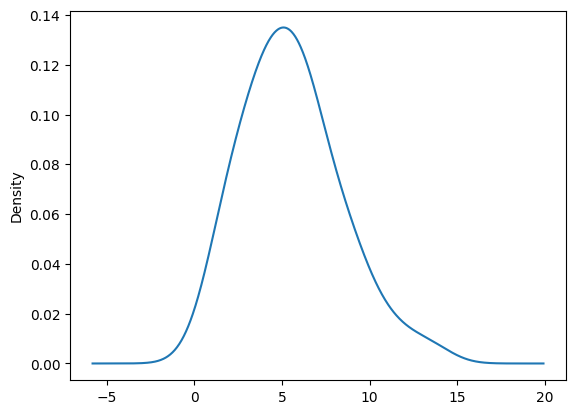

In [12]:
df_borr_state.CP100.plot.kde()

In [13]:
import cvxpy as cp
import numpy as np

def learn_laplacian(signals, alpha=0.1):
    n = signals.shape[0]  # Number of nodes
    L = cp.Variable((n, n), symmetric=True)
    
    # TV Minimization for a set of signals X
    # Total Variation = sum(x_i^T L x_i)
    total_variation = 0
    for i in range(signals.shape[1]):
        x = signals[:, i]
        total_variation += cp.quad_form(x, L)
    
    # Objective: Minimize TV + regularization
    # Using Frobenius norm penalty for sparsity
    objective = cp.Minimize(total_variation + alpha * cp.norm(L, 'fro'))
    
    # Constraints
    constraints = [
        L @ np.ones(n) == 0,             # Row sums = 0
        cp.diag(L) >= 0,                 # Positive diagonal
        cp.trace(L) == n,                # Trace = Number of nodes
    ]
    # Off-diagonal elements <= 0 (implicitly handles non-positive off-diagonals)
    for i in range(n):
        for j in range(i + 1, n):
            constraints.append(L[i, j] <= 0)
            
    prob = cp.Problem(objective, constraints)
    prob.solve()
    
    return L.value



In [14]:
import numpy as np
from scipy.linalg import solve

def smooth_signal_laplacian(X, L, alpha):
    """
    Minimizes the objective function ||Y - X||_F^2 + alpha * Tr(X.T @ L @ X)
    by solving the linear system (I + alpha * L) @ X = Y.

    Parameters:
    Y (np.ndarray): The original signal matrix.
    L (np.ndarray): The Laplacian matrix (assumed to be square and symmetric).
    alpha (float): The regularization parameter.

    Returns:
    np.ndarray: The optimized (smoothed) signal matrix X.
    """
    # Ensure L is a square matrix
    if L.shape[0] != L.shape[1]:
        raise ValueError("Laplacian matrix L must be square.")

    # Construct the coefficient matrix A = (I + alpha * L)
    # The identity matrix I should have the same dimensions as L
    I = np.eye(L.shape[0])
    A = I + alpha * L

    # Solve the linear system A @ X = Y for X
    # scipy.linalg.solve is used for its efficiency and stability
    # The function handles Y being a 1D vector or a 2D matrix (multiple signals/columns)
    Y_smoothed = solve(A, X)
    
    return Y_smoothed






In [15]:
# this is the algorithm used in https://arxiv.org/abs/1406.7842
max_iter = 100
X = df_borr_state.CP100.values.reshape(-1,1)
Y = X
iter_num = 1
alpha_val = 0.5
while iter_num <= max_iter:
    learned_L = learn_laplacian(Y)
    Y = smooth_signal_laplacian(X, learned_L, alpha_val)
    iter_num += 1
    if iter_num % 10 == 0:
        print(f"Completed {iter_num} iterations!")
    


Completed 10 iterations!
Completed 20 iterations!
Completed 30 iterations!
Completed 40 iterations!
Completed 50 iterations!
Completed 60 iterations!
Completed 70 iterations!
Completed 80 iterations!
Completed 90 iterations!
Completed 100 iterations!


In [17]:
import networkx as nx
# Since Laplacian L = D - A, off-diagonal elements are -W_ij
# A threshold is needed for numerical precision
threshold = 1e-4
adj = np.abs(learned_L)
np.fill_diagonal(adj, 0) # Remove diagonal entries


# Create an empty undirected graph
G = nx.Graph()
# Print neighbors
for i in range(adj.shape[0]):
    neighbors = np.where(adj[i, :] > threshold)[0]
    #print(f"Node {i} neighbors: {neighbors}")
    for j in neighbors:
        G.add_edge(i,j.item())

In [18]:
mapping = {k:df_borr_state.loc[k, "BorrState"] for k in df_borr_state.index}

In [19]:
G = nx.relabel_nodes(G, mapping)

In [20]:
G.edges()

EdgeView([('NJ', 'TX'), ('IL', 'CA'), ('CO', 'HI'), ('HI', 'MD'), ('VA', 'SD'), ('MS', 'DC'), ('DC', 'TN'), ('DC', 'GA'), ('TN', 'GA'), ('TN', 'DE'), ('GA', 'DE'), ('OH', 'OR'), ('OH', 'MO'), ('OR', 'MO'), ('OR', 'MI'), ('OR', 'WY'), ('MO', 'MI'), ('MO', 'WY'), ('MI', 'WY'), ('RI', 'SC'), ('RI', 'IA'), ('SC', 'IA'), ('WA', 'CT'), ('CT', 'WI'), ('WI', 'PA'), ('MN', 'NC'), ('MN', 'UT'), ('NC', 'UT'), ('NM', 'KS'), ('NM', 'OK'), ('KS', 'OK'), ('KS', 'IN'), ('KS', 'MA'), ('OK', 'IN'), ('OK', 'MA'), ('IN', 'MA'), ('NE', 'KY'), ('AR', 'NH'), ('MT', 'ND'), ('WV', 'ID')])

In [21]:
G

In [22]:
import plotly.graph_objects as go


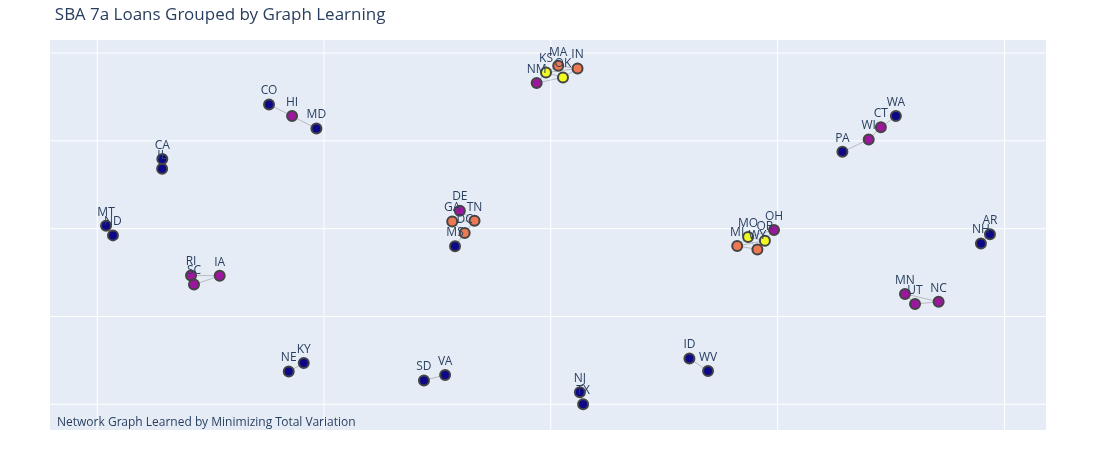

In [23]:
import networkx as nx
import plotly.graph_objects as go


# Get positions for the nodes using a layout algorithm (e.g., spring layout)
pos = nx.spring_layout(G)

# 2. Create Edges
# Add edges as disconnected lines in a single trace
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None) # Separates lines to prevent connecting between distinct edges
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

# 3. Create Nodes with Labels
node_x = []
node_y = []
node_labels = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_labels.append(f'{node}') # Example labels

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text', # Add text to markers
    hoverinfo='text',
    text=node_labels, # Assign labels to text
    textposition="top center", # Position the labels
    marker=dict(
        showscale=False,
        size=10,
        color=[],
        line_width=2))

# Optional: Color nodes by degree
node_adjacencies = []
for node, adjacencies in enumerate(G.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))
node_trace.marker.color = node_adjacencies

# 4. Create the Figure and set the height
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title='SBA 7a Loans Grouped by Graph Learning',
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=20,l=50,r=50,t=40),
                    annotations=[ dict(
                        text="Network Graph Learned by Minimizing Total Variation",
                        showarrow=False,
                        xref="paper", yref="paper",
                        x=0.005, y= -0.002 ) ],
                    xaxis=dict(showgrid=True, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=True, zeroline=False, showticklabels=False),
                    autosize=False,
                    height=450, # Set the height to approximately half a page (in px)
                    width=700 # Optional: set width as well
                )
            )

# 5. Display the figure
fig.show()


In [24]:
df_borr_state["smoothed_sig"] = Y

In [25]:
df_borr_state

,BorrState,borr_count,num_chgoffs,chgoff_prop,CP100,smoothed_sig
0,LA,267,36,0.134831,13.483146,13.483146
1,NV,458,54,0.117904,11.790393,11.790393
2,FL,2759,294,0.106560,10.656035,10.656035
3,NY,2102,211,0.100381,10.038059,10.038059
4,AL,238,22,0.092437,9.243697,9.243697
5,NJ,1155,102,0.088312,8.831169,8.822535
6,TX,3012,265,0.087981,8.798141,8.806774
7,IL,1556,133,0.085476,8.547558,8.509600
8,CA,5256,441,0.083904,8.390411,8.428368
9,AZ,962,78,0.081081,8.108108,8.108108


In [26]:
components_generator = nx.connected_components(G)

# Convert the generator to a list to view the components
components_list = list(components_generator)

print(components_list)

[{'TX', 'NJ'}, {'IL', 'CA'}, {'CO', 'HI', 'MD'}, {'SD', 'VA'}, {'DC', 'MS', 'GA', 'TN', 'DE'}, {'OH', 'MI', 'OR', 'MO', 'WY'}, {'RI', 'IA', 'SC'}, {'CT', 'WI', 'PA', 'WA'}, {'UT', 'NC', 'MN'}, {'OK', 'IN', 'NM', 'MA', 'KS'}, {'KY', 'NE'}, {'AR', 'NH'}, {'MT', 'ND'}, {'WV', 'ID'}]


In [27]:
def find_all_indices_of_key(key_to_find):
  """
  Finds all indices in a list of sets where the specified key is present.

  Args:
    list_of_sets: A list containing set objects.
    key_to_find: The key to search for.

  Returns:
    A list of indices where the key was found.
  """
  indices = [i for i, current_set in enumerate(components_list) if key_to_find in current_set]
  return indices

# Example Usage:
my_list_of_sets_2 = components_list
key_2 = "VA"

all_indices = find_all_indices_of_key(key_2)

print(f"The key '{key_2}' was found at indices: {all_indices}")

# Output:
# The key '1' was found at indices: [0, 1, 2]


The key 'VA' was found at indices: [3]


In [28]:
df_borr_state["conn_comp"] = df_borr_state["BorrState"].apply(find_all_indices_of_key)

In [ ]:
df_borr_state